In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

**Import Libraries**

In [3]:
import os
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported")

Libraries imported


**Dataset Overview**

In [11]:
!find /kaggle/input -type d | head -50

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/abrards
/kaggle/input/datasets/abrards/dataset-of-happy-and-sad-face
/kaggle/input/datasets/abrards/dataset-of-happy-and-sad-face/sad
/kaggle/input/datasets/abrards/dataset-of-happy-and-sad-face/sad/sad
/kaggle/input/datasets/abrards/dataset-of-happy-and-sad-face/happy
/kaggle/input/datasets/abrards/dataset-of-happy-and-sad-face/happy/happy


In [13]:
happy_path = "/kaggle/input/datasets/abrards/dataset-of-happy-and-sad-face/happy/happy"
sad_path = "/kaggle/input/datasets/abrards/dataset-of-happy-and-sad-face/sad/sad"

In [15]:
happy_count = len(os.listdir(happy_path))
sad_count = len(os.listdir(sad_path))

print("Happy Images :", happy_count)
print("Sad Images   :", sad_count)
print("Total Images :", happy_count + sad_count)

Happy Images : 90
Sad Images   : 90
Total Images : 180


**Class Distribution**

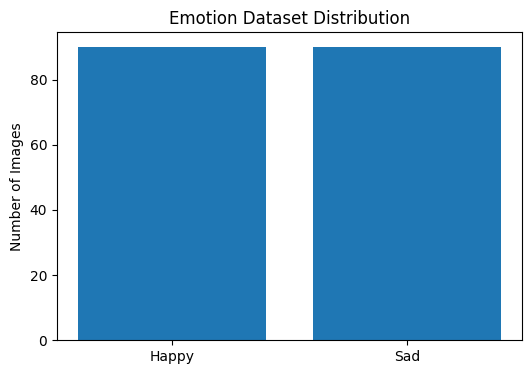

In [16]:
import matplotlib.pyplot as plt

classes = ["Happy", "Sad"]
counts = [happy_count, sad_count]

plt.figure(figsize=(6,4))
plt.bar(classes, counts)
plt.title("Emotion Dataset Distribution")
plt.ylabel("Number of Images")
plt.show()

**Display Sample Images**

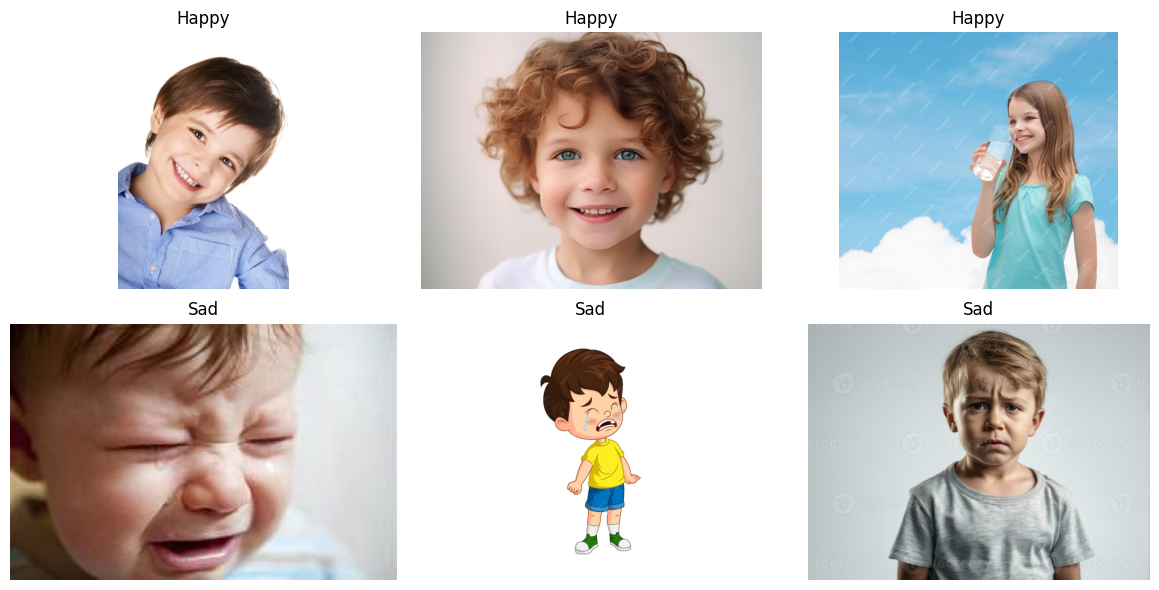

In [17]:
import cv2
import matplotlib.pyplot as plt

happy_images = os.listdir(happy_path)
sad_images = os.listdir(sad_path)

plt.figure(figsize=(12,6))

for i in range(3):

    img = cv2.imread(os.path.join(happy_path, happy_images[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title("Happy")
    plt.axis("off")

for i in range(3):

    img = cv2.imread(os.path.join(sad_path, sad_images[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+4)
    plt.imshow(img)
    plt.title("Sad")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Check Image Sizes**

In [18]:
from PIL import Image

sample_sizes = []

for img_name in happy_images[:10]:
    img = Image.open(os.path.join(happy_path, img_name))
    sample_sizes.append(img.size)

print(sample_sizes)

[(600, 900), (626, 471), (2000, 1837), (668, 800), (240, 240), (471, 626), (1637, 2443), (1280, 853), (306, 396), (328, 500)]


**Check Image Dimensions Distribution**

In [19]:
widths = []
heights = []

for folder in [happy_path, sad_path]:

    for img_name in os.listdir(folder):

        img = Image.open(os.path.join(folder, img_name))

        widths.append(img.size[0])
        heights.append(img.size[1])

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height:", min(heights))
print("Maximum Height:", max(heights))

Minimum Width : 166
Maximum Width : 3023
Minimum Height: 133
Maximum Height: 3023


**Phase 2: Image Preprocessing**

**Load Images**

In [24]:
import cv2
import numpy as np
import os

X = []
y = []

Happy Images

In [25]:
for img_name in os.listdir(happy_path):

    img_path = os.path.join(happy_path, img_name)

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = cv2.resize(img, (64, 64))

    X.append(img)
    y.append(1)

**Sad Images**

In [26]:
for img_name in os.listdir(sad_path):

    img_path = os.path.join(sad_path, img_name)

    img = cv2.imread(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = cv2.resize(img, (64, 64))

    X.append(img)
    y.append(0)

**Convert to NumPy Arrays**

In [27]:
X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (180, 64, 64)
y Shape: (180,)


**Visualize Processed Images**

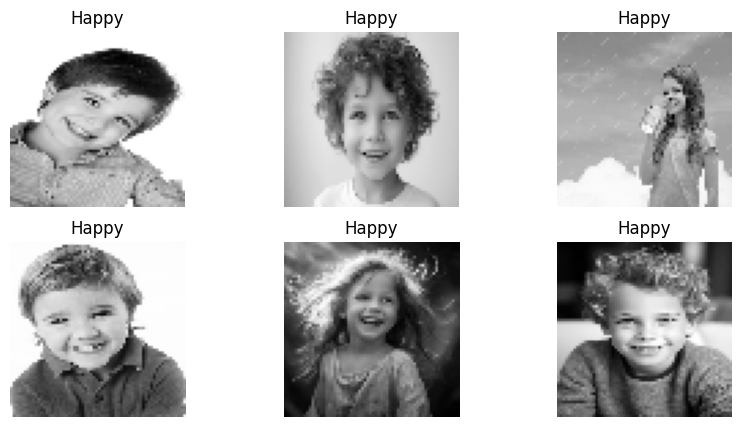

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(6):

    plt.subplot(2,3,i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title("Happy" if y[i]==1 else "Sad")
    plt.axis("off")

plt.show()

**Phase 3: Feature Extraction**

In [30]:
X_flat = X.reshape(len(X), -1)

print("Original Shape :", X.shape)
print("Flattened Shape:", X_flat.shape)

Original Shape : (180, 64, 64)
Flattened Shape: (180, 4096)


**Phase 4: Train-Test Split (80/20)**

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 144
Testing Samples : 36


**Model 1: Logistic Regression**

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=5000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.6388888888888888


**Model 2: SVM**

In [33]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.7222222222222222


**Model 3: Random Forest**

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.5833333333333334


**Compare All Models**

In [35]:
print("Logistic Regression :", round(lr_acc*100,2), "%")
print("SVM                 :", round(svm_acc*100,2), "%")
print("Random Forest       :", round(rf_acc*100,2), "%")

Logistic Regression : 63.89 %
SVM                 : 72.22 %
Random Forest       : 58.33 %
